<a href="https://colab.research.google.com/github/esprydi/cat-and-dog-classification-image/blob/master/Cats_and_Dogs_Classification_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Packages and Libary

In [1]:
import os

# Data Loading


In [2]:
# Import module yang disediakan google colab untuk kebutuhan upload file

from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1) (1).json


{'kaggle (1) (1).json': b'{"username":"endangsupriyadi","key":"446409872ad307d55c245a177561699b"}'}

### Mengunduh dan Mengekstrak Dataset 'Cats and Dogs Classification'


In [3]:
# Tentukan slug dataset untuk 'Dog and Cat Classification Dataset' yang baru
dataset_slug = 'bhavikjikadara/dog-and-cat-classification-dataset'
output_zip_name = dataset_slug.split('/')[-1] + '.zip'

# Buat direktori untuk menyimpan dataset
output_dir = './dog_cat_classification_dataset'
os.makedirs(output_dir, exist_ok=True)
os.chdir(output_dir)

print(f"Mengunduh dataset: {dataset_slug}...")
!kaggle datasets download -d {dataset_slug}

print(f"Mengekstrak {output_zip_name}...")
# Pastikan nama file zip yang benar diekstrak
if os.path.exists(output_zip_name):
    !unzip -q {output_zip_name} -d .
    os.remove(output_zip_name) # Hapus file zip setelah diekstrak
    print("Ekstraksi selesai.")
else:
    print(f"ERROR: File {output_zip_name} tidak ditemukan. Mungkin nama file yang diunduh berbeda.")

os.chdir('..') # Kembali ke direktori kerja utama

# Verifikasi struktur folder
print("\nStruktur folder dataset:")
for root, dirs, files in os.walk(output_dir):
    level = root.replace(output_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]: # Tampilkan hanya beberapa file pertama untuk ringkas
        print(f'{subindent}{f}')
    if len(files) > 3:
        print(f'{subindent}...')


Mengunduh dataset: bhavikjikadara/dog-and-cat-classification-dataset...
Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
100% 775M/775M [00:04<00:00, 176MB/s]

Mengekstrak dog-and-cat-classification-dataset.zip...
replace ./PetImages/Cat/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./PetImages/Cat/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Ekstraksi selesai.

Struktur folder dataset:
dog_cat_classification_dataset/
    PetImages/
        Dog/
            11728.jpg
            9289.jpg
            12312.jpg
            ...
        Cat/
            11728.jpg
            9289.jpg
            12312.jpg
            ...
    train/
        Dog/
            12312.jpg
            9632.jpg
            2107.jpg
            ...
        Cat/
            11728.jpg
            9289.jpg
            12312.jpg
            ...
    validation/
        Dog/
            11728.jpg
            9289.jpg
            1446.jpg
    

# Data Preparation

In [4]:
import os
import shutil

### Mengatur Struktur Dataset untuk Pelatihan Model

Kita akan membuat struktur direktori sebagai berikut:

```
dog_cat_classification_dataset/
├── train/
│   ├── cats/
│   └── dogs/
├── validation/
│   ├── cats/
│   └── dogs/
└── test/
    ├── cats/
    └── dogs/
```

Kemudian, kita akan membagi gambar dari folder `PetImages` ke dalam direktori `train`, `validation`, dan `test` dengan rasio 70:15:15.

In [5]:
# Tentukan path dasar dataset yang sudah diekstrak
base_dir = './dog_cat_classification_dataset'
original_data_dir = os.path.join(base_dir, 'PetImages')

# Definisikan direktori baru untuk train, validation, dan test
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

train_cats_dir = os.path.join(train_dir, 'Cat')
train_dogs_dir = os.path.join(train_dir, 'Dog')
validation_cats_dir = os.path.join(validation_dir, 'Cat')
validation_dogs_dir = os.path.join(validation_dir, 'Dog')
test_cats_dir = os.path.join(test_dir, 'Cat')
test_dogs_dir = os.path.join(test_dir, 'Dog')

# Buat direktori jika belum ada
for directory in [train_cats_dir, train_dogs_dir, validation_cats_dir, validation_dogs_dir, test_cats_dir, test_dogs_dir]:
    os.makedirs(directory, exist_ok=True)

print("Struktur direktori baru telah dibuat.")

Struktur direktori baru telah dibuat.


In [6]:
def split_data(source_dir, train_dest_dir, val_dest_dir, test_dest_dir, split_ratio=(0.7, 0.15, 0.15)):
    files = [os.path.join(source_dir, fname) for fname in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, fname))]
    files = [f for f in files if f.endswith(('.jpg', '.jpeg', '.png'))] # Filter hanya file gambar
    np.random.shuffle(files)

    num_files = len(files)
    num_train = int(num_files * split_ratio[0])
    num_val = int(num_files * split_ratio[1])
    # num_test = num_files - num_train - num_val # Calculate test to ensure all files are used
    num_test = int(num_files * split_ratio[2])

    train_files = files[:num_train]
    val_files = files[num_train : num_train + num_val]
    test_files = files[num_train + num_val : num_train + num_val + num_test]

    print(f"Total files in {source_dir}: {num_files}")
    print(f"Moving {len(train_files)} to {train_dest_dir}")
    for f in train_files:
        shutil.copy(f, train_dest_dir)

    print(f"Moving {len(val_files)} to {val_dest_dir}")
    for f in val_files:
        shutil.copy(f, val_dest_dir)

    print(f"Moving {len(test_files)} to {test_dest_dir}")
    for f in test_files:
        shutil.copy(f, test_dest_dir)

    print(f"Finished splitting data for {source_dir}")

import numpy as np # Import numpy for random.shuffle

# Split Cat images
cat_source_dir = os.path.join(original_data_dir, 'Cat')

# Remove any non-image files like 'Thumbs.db' or corrupt files
corrupt_cat_file = os.path.join(cat_source_dir, '666.jpg')
if os.path.exists(corrupt_cat_file):
    os.remove(corrupt_cat_file)
    print(f"Removed corrupt file: {corrupt_cat_file}")

split_data(cat_source_dir, train_cats_dir, validation_cats_dir, test_cats_dir)

# Split Dog images
dog_source_dir = os.path.join(original_data_dir, 'Dog')

# Remove any non-image files like 'Thumbs.db' or corrupt files
corrupt_dog_file = os.path.join(dog_source_dir, '11702.jpg')
if os.path.exists(corrupt_dog_file):
    os.remove(corrupt_dog_file)
    print(f"Removed corrupt file: {corrupt_dog_file}")

split_data(dog_source_dir, train_dogs_dir, validation_dogs_dir, test_dogs_dir)

print("Pembagian dataset selesai!")

# Verifikasi jumlah gambar di setiap direktori
print("\nVerifikasi jumlah gambar:")
print(f"Training Cat images: {len(os.listdir(train_cats_dir))}")
print(f"Training Dog images: {len(os.listdir(train_dogs_dir))}")
print(f"Validation Cat images: {len(os.listdir(validation_cats_dir))}")
print(f"Validation Dog images: {len(os.listdir(validation_dogs_dir))}")
print(f"Test Cat images: {len(os.listdir(test_cats_dir))}")
print(f"Test Dog images: {len(os.listdir(test_dogs_dir))}")

Total files in ./dog_cat_classification_dataset/PetImages/Cat: 12499
Moving 8749 to ./dog_cat_classification_dataset/train/Cat
Moving 1874 to ./dog_cat_classification_dataset/validation/Cat
Moving 1874 to ./dog_cat_classification_dataset/test/Cat
Finished splitting data for ./dog_cat_classification_dataset/PetImages/Cat
Total files in ./dog_cat_classification_dataset/PetImages/Dog: 12499
Moving 8749 to ./dog_cat_classification_dataset/train/Dog
Moving 1874 to ./dog_cat_classification_dataset/validation/Dog
Moving 1874 to ./dog_cat_classification_dataset/test/Dog
Finished splitting data for ./dog_cat_classification_dataset/PetImages/Dog
Pembagian dataset selesai!

Verifikasi jumlah gambar:
Training Cat images: 11361
Training Dog images: 11394
Validation Cat images: 3484
Validation Dog images: 3483
Test Cat images: 3463
Test Dog images: 3464


### Pra-pemrosesan dan Augmentasi Data dengan `ImageDataGenerator`

Kita akan menggunakan `ImageDataGenerator` dari Keras untuk:

*   **Mengubah ukuran semua gambar** menjadi dimensi target (misalnya, 150x150 piksel).
*   **Normalisasi piksel** menjadi rentang `[0, 1]`.
*   **Melakukan augmentasi data** pada set pelatihan untuk meningkatkan keberagaman data dan mengurangi *overfitting*.



In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Definisikan parameter gambar
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Generator untuk data pelatihan dengan augmentasi
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalisasi piksel ke [0, 1]
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generator untuk data validasi/pengujian (hanya normalisasi, tanpa augmentasi)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Memuat gambar dari direktori menggunakan flow_from_directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = validation_test_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = validation_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("Data generators telah disiapkan.")

Found 22755 images belonging to 2 classes.
Found 6967 images belonging to 2 classes.
Found 6927 images belonging to 2 classes.
Data generators telah disiapkan.


### Peningkatan Akurasi Model dengan Transfer Learning (MobileNetV2)

Untuk meningkatkan akurasi model secara signifikan, kita bisa memanfaatkan *Transfer Learning*. Ini melibatkan penggunaan model yang sudah dilatih pada dataset yang sangat besar (seperti ImageNet) dan kemudian menyesuaikannya untuk tugas kita. MobileNetV2 adalah pilihan yang baik karena ringan dan efisien.

Langkah-langkahnya adalah:
1.  Muat model dasar MobileNetV2 yang sudah dilatih sebelumnya, tanpa lapisan klasifikasi teratasnya.
2.  Bekukan lapisan-lapisan model dasar agar tidak terlatih ulang.
3.  Tambahkan lapisan klasifikasi baru di atas model dasar.
4.  Latih model baru ini.

In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# 1. Muat model dasar MobileNetV2 yang sudah dilatih sebelumnya
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                          include_top=False, # Jangan sertakan lapisan klasifikasi teratas
                          weights='imagenet')

# 2. Bekukan lapisan-lapisan model dasar
# Ini mencegah bobot base_model diperbarui selama pelatihan
base_model.trainable = False

# 3. Tambahkan lapisan klasifikasi baru di atas model dasar
x = base_model.output
x = GlobalAveragePooling2D()(x) # Lapisan untuk mengubah output menjadi vektor
x = Dense(128, activation='relu')(x) # Lapisan Dense tambahan
predictions = Dense(1, activation='sigmoid')(x) # Lapisan output untuk klasifikasi biner

model_tl = Model(inputs=base_model.input, outputs=predictions)

# Tampilkan ringkasan model baru
model_tl.summary()


/tmp/ipykernel_10834/1596269951.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Kompilasi Model Transfer Learning

Kita akan mengkompilasi model yang baru dibangun dengan optimizer dan fungsi loss yang sama, tetapi mungkin dengan learning rate yang lebih rendah untuk fine-tuning.

In [9]:
from tensorflow.keras import optimizers

# Kompilasi model
model_tl.compile(loss='binary_crossentropy',
                optimizer=optimizers.RMSprop(learning_rate=2e-5), # Learning rate yang lebih rendah
                metrics=['accuracy'])

print("Model Transfer Learning siap untuk dilatih!")

Model Transfer Learning siap untuk dilatih!


### Pelatihan Model Transfer Learning



In [10]:
EPOCHS_TL = 10 # Anda bisa menyesuaikan jumlah epoch untuk transfer learning

history_tl = model_tl.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS_TL,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Pelatihan model Transfer Learning selesai!")


Epoch 1/10
634/711 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step - accuracy: 0.8012 - loss: 0.4116

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


711/711 ━━━━━━━━━━━━━━━━━━━━ 192s 247ms/step - accuracy: 0.8748 - loss: 0.2827 - val_accuracy: 0.9543 - val_loss: 0.1148
Epoch 2/10
  1/711 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9062 - loss: 0.2347

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


711/711 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9062 - loss: 0.2347 - val_accuracy: 0.9558 - val_loss: 0.1134
Epoch 3/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 167s 234ms/step - accuracy: 0.9147 - loss: 0.1978 - val_accuracy: 0.9567 - val_loss: 0.1061
Epoch 4/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.9688 - loss: 0.1415 - val_accuracy: 0.9575 - val_loss: 0.1028
Epoch 5/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 202s 283ms/step - accuracy: 0.9216 - loss: 0.1853 - val_accuracy: 0.9615 - val_loss: 0.0950
Epoch 6/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9375 - loss: 0.2058 - val_accuracy: 0.9618 - val_loss: 0.0959
Epoch 7/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 161s 226ms/step - accuracy: 0.9270 - loss: 0.1777 - val_accuracy: 0.9559 - val_loss: 0.1103
Epoch 8/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9062 - loss: 0.1825 - val_accuracy: 0.9555 - val_loss: 0.1116
Epoch 9/10
711/711 ━━━━━━━━━━━━━━━━━━━━ 203s 285ms/step - accuracy: 0.9280 - loss: 0.1735 - val

### Visualisasi dan Evaluasi Model Transfer Learning



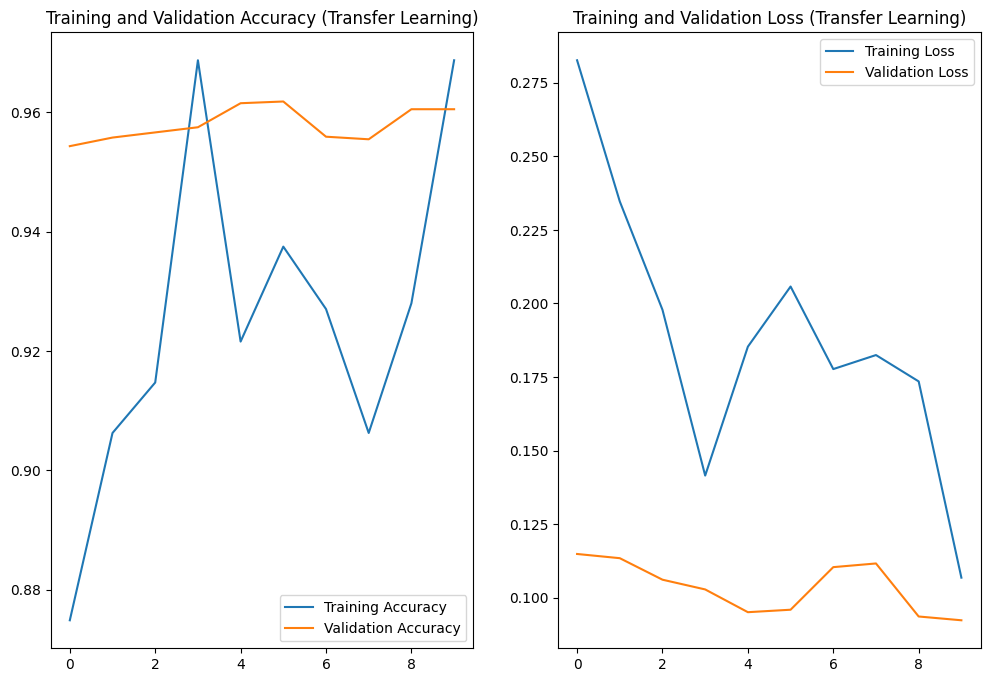

216/216 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9606 - loss: 0.0978
Test Loss (Transfer Learning): 0.0978
Test Accuracy (Transfer Learning): 0.9606


In [11]:
import matplotlib.pyplot as plt

acc_tl = history_tl.history['accuracy']
val_acc_tl = history_tl.history['val_accuracy']
loss_tl = history_tl.history['loss']
val_loss_tl = history_tl.history['val_loss']

epochs_range_tl = range(EPOCHS_TL)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_tl, acc_tl, label='Training Accuracy')
plt.plot(epochs_range_tl, val_acc_tl, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Transfer Learning)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_tl, loss_tl, label='Training Loss')
plt.plot(epochs_range_tl, val_loss_tl, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Transfer Learning)')
plt.show()

loss_tl_eval, accuracy_tl_eval = model_tl.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE)
print(f'Test Loss (Transfer Learning): {loss_tl_eval:.4f}')
print(f'Test Accuracy (Transfer Learning): {accuracy_tl_eval:.4f}')

In [17]:
import os

# Definisikan path untuk SavedModel
saved_model_tl_path = './saved_model_tl'

# Buat direktori SavedModel jika belum ada
os.makedirs(saved_model_tl_path, exist_ok=True)

# Simpan model_tl dalam format SavedModel menggunakan model.export()
model_tl.export(saved_model_tl_path)

print(f'Model Transfer Learning berhasil disimpan dalam format SavedModel di: {saved_model_tl_path}')

Saved artifact at './saved_model_tl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139514523881488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139514523882064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139514523884752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139514523884368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139514523883216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139514523884944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139514523883408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139514523885520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139514523885136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139514523883024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13951452388168

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Gambar yang diprediksi: ./dog_cat_classification_dataset/test/Cat/12190.jpg
Prediksi: Cat dengan kepercayaan 99.18%


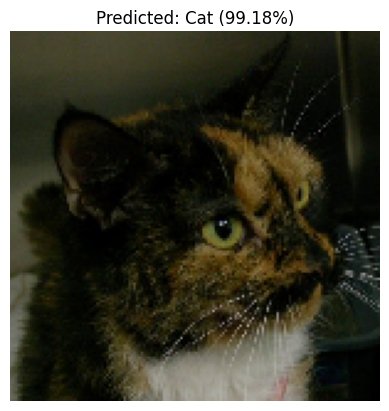

In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import random

# Fungsi untuk memuat dan memproses gambar
def load_and_preprocess_image(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Tambahkan dimensi batch
    img_array /= 255.0  # Normalisasi seperti yang dilakukan pada training
    return img_array, img

# Pilih gambar acak dari direktori test_cats_dir atau test_dogs_dir

# Tentukan path ke direktori Cat dan Dog dalam test set
test_cat_images = [os.path.join(test_cats_dir, f) for f in os.listdir(test_cats_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
test_dog_images = [os.path.join(test_dogs_dir, f) for f in os.listdir(test_dogs_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Gabungkan kedua daftar dan pilih satu secara acak
all_test_images = test_cat_images + test_dog_images
random_img_path = random.choice(all_test_images)

# Muat dan pra-proses gambar
img_to_predict, original_img = load_and_preprocess_image(random_img_path)

# Lakukan prediksi
prediction = model_tl.predict(img_to_predict)

# Ambil label kelas dari generator
class_labels = list(train_generator.class_indices.keys()) # ['Cat', 'Dog']

# Interpretasi hasil prediksi
# Jika nilai mendekati 0, kemungkinan Cat. Jika mendekati 1, kemungkinan Dog.
predicted_class_index = (prediction > 0.5).astype(int)[0][0]
predicted_label = class_labels[predicted_class_index]
confidence = prediction[0][0] if predicted_class_index == 1 else (1 - prediction[0][0])

print(f"Gambar yang diprediksi: {random_img_path}")
print(f"Prediksi: {predicted_label} dengan kepercayaan {confidence*100:.2f}%")

# Tampilkan gambar
plt.imshow(original_img)
plt.title(f"Predicted: {predicted_label} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()

### Konversi Model ke TensorFlow Lite (TF-Lite)

Untuk mengoptimalkan model agar berjalan di perangkat *mobile* atau *edge*, kita bisa mengonversinya ke format TensorFlow Lite (`.tflite`).

In [19]:
import tensorflow as tf

# Inisialisasi TensorFlow Lite Converter
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_tl_path)

# Konversi model
tflite_model = converter.convert()

# Simpan model TF-Lite ke file
tflite_model_path = 'model_tl.tflite'
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f'Model Transfer Learning berhasil disimpan dalam format TF-Lite di: {tflite_model_path}')

Model Transfer Learning berhasil disimpan dalam format TF-Lite di: model_tl.tflite


### Inferensi Menggunakan Model TensorFlow Lite (TF-Lite)

Gambar yang diprediksi (TF-Lite): ./dog_cat_classification_dataset/test/Cat/3235.jpg
Prediksi (TF-Lite): Cat dengan kepercayaan 99.88%


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


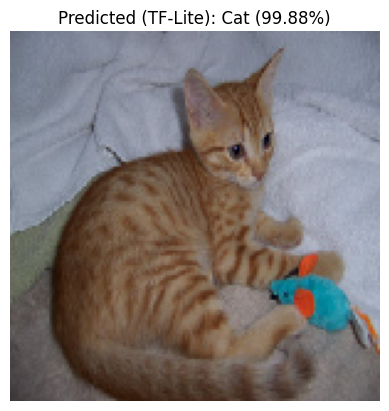

In [21]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import random
import os

# Pastikan path model TF-Lite sudah benar
tflite_model_path = 'model_tl.tflite'

# Load the TFLite model and allocate tensors.
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

# Get input and output tensors.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Fungsi untuk memuat dan memproses gambar (re-use from previous inference)
def load_and_preprocess_image_for_tflite(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    # TFLite models often expect float32 input
    img_array = img_array.astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)  # Tambahkan dimensi batch
    img_array /= 255.0  # Normalisasi piksel ke [0, 1]
    return img_array, img

# Pilih gambar acak dari direktori test_cats_dir atau test_dogs_dir
# Pastikan variabel ini sudah didefinisikan dari langkah sebelumnya
# test_cat_images, test_dog_images, all_test_images

# Jika belum didefinisikan, kita definisikan ulang di sini untuk keamanan
if 'test_cat_images' not in locals():
    test_cats_dir = os.path.join('./dog_cat_classification_dataset', 'test', 'Cat')
    test_dog_images = os.path.join('./dog_cat_classification_dataset', 'test', 'Dog')
    test_cat_images = [os.path.join(test_cats_dir, f) for f in os.listdir(test_cats_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    test_dog_images = [os.path.join(test_dogs_dir, f) for f in os.listdir(test_dogs_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    all_test_images = test_cat_images + test_dog_images

random_img_path = random.choice(all_test_images)

# Muat dan pra-proses gambar untuk TFLite
input_data, original_img = load_and_preprocess_image_for_tflite(random_img_path)

# Set the tensor to point to the input data to be inferred
interpreter.set_tensor(input_details[0]['index'], input_data)

# Run the inference
interpreter.invoke()

# Get the interpretation result
tflite_prediction = interpreter.get_tensor(output_details[0]['index'])

# Ambil label kelas dari generator (diasumsikan train_generator sudah ada)
# Jika belum ada, bisa didefinisikan manual: class_labels = ['Cat', 'Dog']
if 'train_generator' in locals():
    class_labels = list(train_generator.class_indices.keys())
else:
    # Fallback jika train_generator tidak tersedia di scope
    class_labels = ['Cat', 'Dog'] # Asumsi urutan kelas yang sama

# Interpretasi hasil prediksi TF-Lite
predicted_class_index = (tflite_prediction > 0.5).astype(int)[0][0]
predicted_label = class_labels[predicted_class_index]
confidence = tflite_prediction[0][0] if predicted_class_index == 1 else (1 - tflite_prediction[0][0])

print(f"Gambar yang diprediksi (TF-Lite): {random_img_path}")
print(f"Prediksi (TF-Lite): {predicted_label} dengan kepercayaan {confidence*100:.2f}%")

# Tampilkan gambar
plt.imshow(original_img)
plt.title(f"Predicted (TF-Lite): {predicted_label} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()

### Konversi Model ke TensorFlow.js (TFJS)

Untuk menggunakan model di lingkungan web atau Node.js, kita akan mengonversinya ke format TensorFlow.js. Pertama, pastikan Anda telah menginstal `tensorflowjs`.

In [20]:
# Instal tensorflowjs_converter jika belum ada
!pip install tensorflowjs

# Buat direktori untuk TFJS
tfjs_model_tl_path = './tfjs_model_tl'
os.makedirs(tfjs_model_tl_path, exist_ok=True)

# Konversi model SavedModel ke TensorFlow.js
# Menggunakan `saved_model_tl_path` yang sudah kita pastikan terisi dengan benar
!tensorflowjs_converter --input_format=tf_saved_model \
  --saved_model_tags=serve \
  {saved_model_tl_path} {tfjs_model_tl_path}

print(f'Model Transfer Learning berhasil disimpan dalam format TensorFlow.js di: {tfjs_model_tl_path}')

2026-03-30 02:48:05.481027: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774838885.500988   20929 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774838885.507565   20929 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774838885.523491   20929 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774838885.523515   20929 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774838885.523518   20929 computation_placer.cc:177] computation placer alr

In [23]:
! pip freeze requirements.txt


absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.3.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.16.0.53.33
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.38.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
c

In [24]:
pip freeze > requirements.txt